<a href="https://colab.research.google.com/github/SantiaGaGo/Financiero---UniAndes-TodosALaU/blob/main/Ejercicio_yfinance_ta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 62 kB 1.1 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0


In [ ]:
pip install ta

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for ta: filename=ta-0.10.2-py3-none-any.whl size=29104 sha256=576f02b6b33e613f702792df000c4bbc820562c0a7f95896daf33aaebad1db11
  Stored in directory: /root/.cache/pip/wheels/31/31/f1/f2ff471bbc5b84a4b973698ceecdd453ae043971791adc3431
Successfully built ta


In [ ]:
#librerias y manejo de tablas
import yfinance as yfin
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import ta

In [ ]:
df= yfin.download('ETH-USD', start='2019-09-01', end='2021-09-01')
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516
...,...,...,...,...,...,...
2021-08-27,3096.406006,3281.840576,3064.485107,3270.600830,3270.600830,18489602004
2021-08-28,3275.104492,3284.845947,3217.403564,3244.403320,3244.403320,13709633698
2021-08-29,3246.770996,3283.235596,3158.840332,3227.002686,3227.002686,13296586731


In [ ]:
#SMA 5 dias
df['SMA_short']=df['Adj Close'].rolling(window=5).mean()

#SMA 20 dias
df['SMA_long']=df['Adj Close'].rolling(window=20).mean()

df.head(21)

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long
Date,,,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576,NaN,NaN
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137,NaN,NaN
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938,NaN,NaN
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494,NaN,NaN
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516,175.937225,NaN
2019-09-06,174.172226,177.718704,168.341339,169.956177,169.956177,6797611878,175.602576,NaN
2019-09-07,169.955276,180.851608,169.444122,178.262619,178.262619,6791531342,175.585629,NaN
2019-09-08,178.282593,182.977081,178.142502,181.355530,181.355530,6472677266,175.956870,NaN
2019-09-09,181.362488,184.149460,177.419357,181.149460,181.149460,7232938985,176.988184,NaN


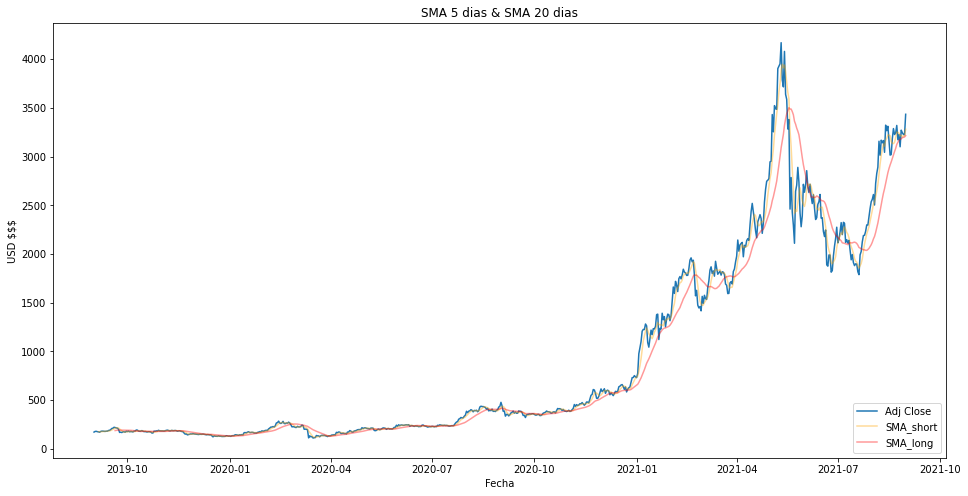

In [ ]:
plt.figure(figsize=(16,8))
plt.title('SMA 5 dias & SMA 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['SMA_short'], color ='orange', alpha=0.4)
plt.plot(df['SMA_long'], color ='red',alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'SMA_short','SMA_long'], loc='lower right')
plt.show()

In [ ]:
#EMA 5 dias
df['EMA_short']= df['Adj Close'].ewm(span=5, adjust=False).mean()

#EMA 20 dias
df['EMA_long']= df['Adj Close'].ewm(span=20, adjust=False).mean()

df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long
Date,,,,,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576,NaN,NaN,171.629425,171.629425
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137,NaN,NaN,173.868734,172.269228
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938,NaN,NaN,175.745599,172.957809
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494,NaN,NaN,175.828029,173.246864
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516,175.937225,NaN,175.291063,173.339270
...,...,...,...,...,...,...,...,...,...,...
2021-08-27,3096.406006,3281.840576,3064.485107,3270.600830,3270.600830,18489602004,3217.511035,3182.296802,3211.738433,3103.066208
2021-08-28,3275.104492,3284.845947,3217.403564,3244.403320,3244.403320,13709633698,3202.540234,3193.830334,3222.626729,3116.526885
2021-08-29,3246.770996,3283.235596,3158.840332,3227.002686,3227.002686,13296586731,3213.449512,3196.787659,3224.085381,3127.048390


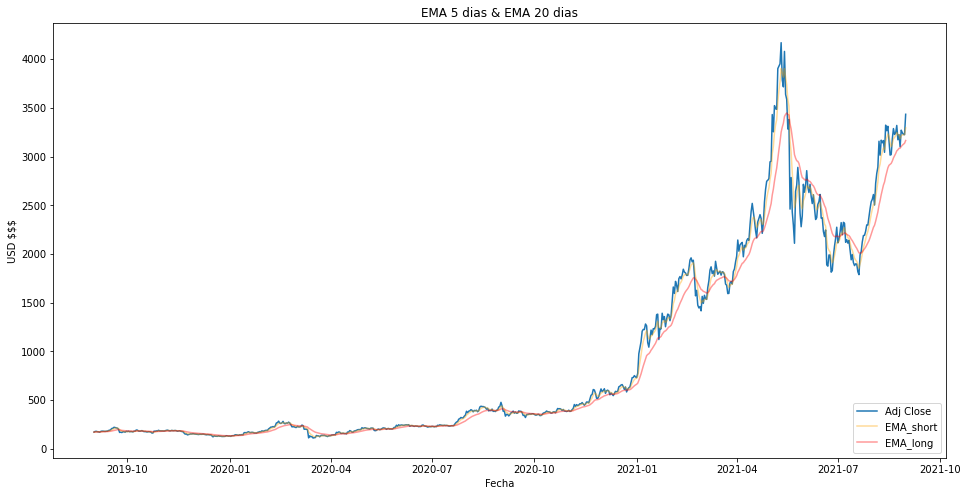

In [ ]:
plt.figure(figsize=(16,8))
plt.title('EMA 5 dias & EMA 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['EMA_short'], color ='orange', alpha=0.4)
plt.plot(df['EMA_long'], color ='red',alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'EMA_short','EMA_long'], loc='lower right')
plt.show()

In [ ]:
#bandas de bollinger
bb= ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)

df['BOL_M']= bb.bollinger_mavg()
df['BOL_U']= bb.bollinger_hband()
df['BOL_D']= bb.bollinger_lband()

df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long,BOL_M,BOL_U,BOL_D
Date,,,,,,,,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576,NaN,NaN,171.629425,171.629425,NaN,NaN,NaN
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137,NaN,NaN,173.868734,172.269228,NaN,NaN,NaN
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938,NaN,NaN,175.745599,172.957809,NaN,NaN,NaN
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494,NaN,NaN,175.828029,173.246864,NaN,NaN,NaN
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516,175.937225,NaN,175.291063,173.339270,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-27,3096.406006,3281.840576,3064.485107,3270.600830,3270.600830,18489602004,3217.511035,3182.296802,3211.738433,3103.066208,3182.296802,3382.027207,2982.566396
2021-08-28,3275.104492,3284.845947,3217.403564,3244.403320,3244.403320,13709633698,3202.540234,3193.830334,3222.626729,3116.526885,3193.830334,3379.434256,3008.226413
2021-08-29,3246.770996,3283.235596,3158.840332,3227.002686,3227.002686,13296586731,3213.449512,3196.787659,3224.085381,3127.048390,3196.787659,3382.526676,3011.048641


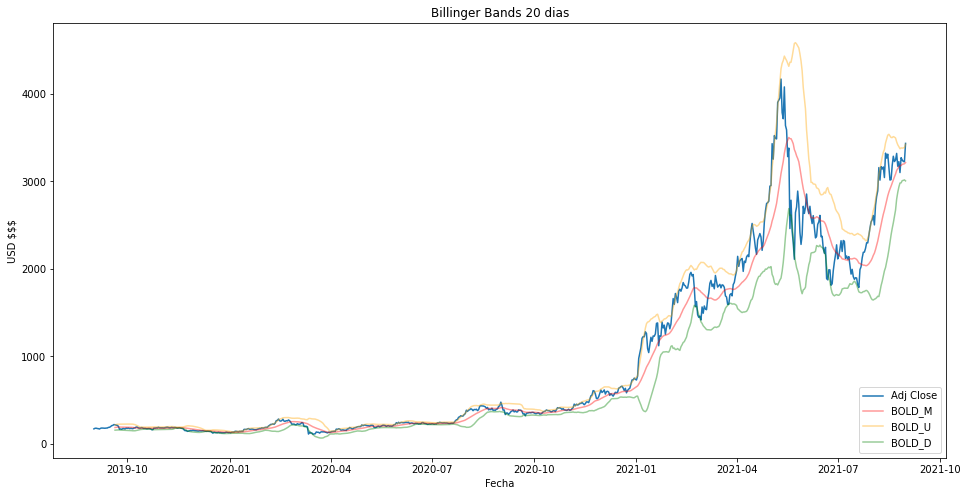

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Billinger Bands 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['BOL_M'], color ='red', alpha=0.4)
plt.plot(df['BOL_U'], color ='orange', alpha=0.4)
plt.plot(df['BOL_D'], color ='green', alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'BOLD_M','BOLD_U','BOLD_D'], loc='lower right')
plt.show()

In [ ]:
#Media movil de convergencia-divergencia (MACD)
df['MACD']= ta.trend.MACD(close=df['Close'], window_fast=12, window_slow=26).macd()
df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long,BOL_M,BOL_U,BOL_D,MACD
Date,,,,,,,,,,,,,,
2019-09-01,172.458405,173.696854,169.531281,171.629425,171.629425,5554799576,NaN,NaN,171.629425,171.629425,NaN,NaN,NaN,NaN
2019-09-02,171.697601,180.145218,170.451691,178.347351,178.347351,6503447137,NaN,NaN,173.868734,172.269228,NaN,NaN,NaN,NaN
2019-09-03,178.357758,182.347992,175.970169,179.499329,179.499329,6962728938,NaN,NaN,175.745599,172.957809,NaN,NaN,NaN,NaN
2019-09-04,179.491989,180.136597,175.325363,175.992889,175.992889,5938120494,NaN,NaN,175.828029,173.246864,NaN,NaN,NaN,NaN
2019-09-05,175.966278,176.163910,171.746826,174.217133,174.217133,5589476516,175.937225,NaN,175.291063,173.339270,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-27,3096.406006,3281.840576,3064.485107,3270.600830,3270.600830,18489602004,3217.511035,3182.296802,3211.738433,3103.066208,3182.296802,3382.027207,2982.566396,152.400210
2021-08-28,3275.104492,3284.845947,3217.403564,3244.403320,3244.403320,13709633698,3202.540234,3193.830334,3222.626729,3116.526885,3193.830334,3379.434256,3008.226413,145.927438
2021-08-29,3246.770996,3283.235596,3158.840332,3227.002686,3227.002686,13296586731,3213.449512,3196.787659,3224.085381,3127.048390,3196.787659,3382.526676,3011.048641,137.805103


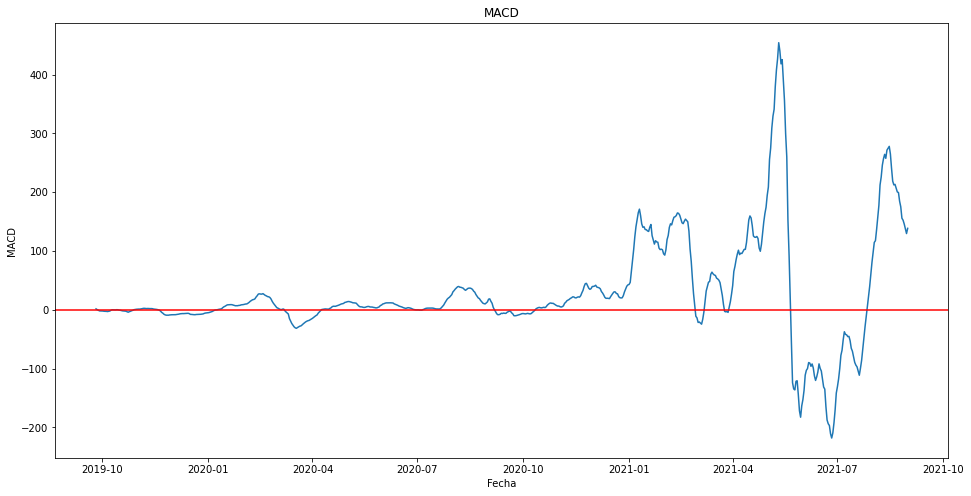

In [ ]:
plt.figure(figsize=(16,8))
plt.title('MACD')
plt.plot(df['MACD'])
plt.xlabel('Fecha')
plt.ylabel('MACD')
plt.axhline(y=0, color='red')
plt.show()

In [ ]:
#retrocesod de fibonacci
max_p=df['Close'].max()
min_p=df['Close'].min()

dif_p=max_p-min_p

r_fibo=np.array([0.236, 0.382, 0.5, 0.618])
levels=max_p-dif_p*r_fibo

levels

array([3210.99068137, 2618.50876775, 2139.65352249, 1660.79827724])

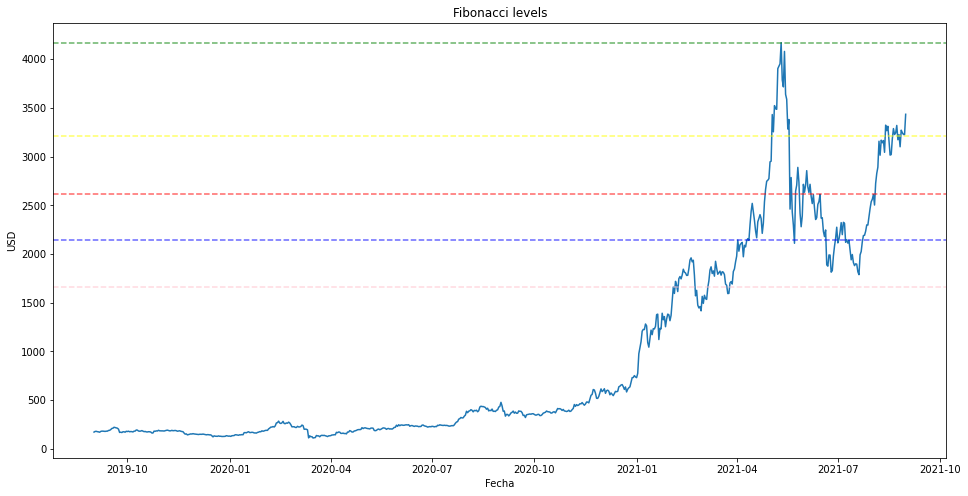

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Fibonacci levels')
plt.plot(df['Close'])
plt.xlabel('Fecha')
plt.ylabel('USD')
plt.axhline(y=max_p, color='green', linestyle='--',alpha=0.6)

plt.axhline(y=levels[0], color='yellow', linestyle='--',alpha=0.6)
plt.axhline(y=levels[1], color='red', linestyle='--',alpha=0.6)
plt.axhline(y=levels[2], color='blue', linestyle='--',alpha=0.6)
plt.axhline(y=levels[3], color='pink', linestyle='--',alpha=0.6)

plt.show()